# Telecom Customer Churn Prediction and Retention Analytics System

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# 🎯 Problem Statement

Customer churn is one of the most significant challenges faced by telecommunication companies. Losing existing customers can lead to decreased revenue and increased customer acquisition costs.

The goal of this project is to build a Machine Learning classification model that predicts whether a customer is likely to churn based on customer demographics, service subscriptions, contract details, and billing information.

By identifying customers at risk of leaving, the company can implement targeted retention strategies, improve customer satisfaction, and reduce revenue loss.

### Objective
Develop a predictive model that classifies customers into:
- **Churn = Yes** (Customer will leave)
- **Churn = No** (Customer will stay)

### Expected Outcome
A machine learning model capable of accurately predicting customer churn and providing insights into the factors that influence customer retention.

# 📊 Telco Customer Churn Dataset

## 👤 Customer Information
- **customerID** – Unique customer identifier
- **gender** – Customer gender
- **SeniorCitizen** – Whether the customer is a senior citizen (0 = No, 1 = Yes)
- **Partner** – Whether the customer has a partner
- **Dependents** – Whether the customer has dependents

---

## 🤝 Customer Relationship
- **tenure** – Number of months the customer has stayed with the company

---

## 📞 Services Used
- **PhoneService** – Whether the customer has phone service
- **MultipleLines** – Whether the customer has multiple phone lines
- **InternetService** – Type of internet service
- **OnlineSecurity** – Online security service subscription
- **OnlineBackup** – Online backup service subscription
- **DeviceProtection** – Device protection plan subscription
- **TechSupport** – Technical support subscription
- **StreamingTV** – Streaming TV subscription
- **StreamingMovies** – Streaming movies subscription

---

## 📄 Contract & Payment Details
- **Contract** – Customer contract type
- **PaperlessBilling** – Whether paperless billing is enabled
- **PaymentMethod** – Customer payment method

---

## 💰 Billing Information
- **MonthlyCharges** – Monthly bill amount
- **TotalCharges** – Total amount charged to the customer

---

## 🎯 Target Variable
- **Churn** – Whether the customer left the company
  - **Yes** → Customer churned
  - **No** → Customer retained

---

## 📌 Dataset Summary

| Category | Features |
|-----------|-----------|
| Customer Information | customerID, gender, SeniorCitizen, Partner, Dependents |
| Customer Relationship | tenure |
| Services Used | PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies |
| Contract & Payment | Contract, PaperlessBilling, PaymentMethod |
| Billing Information | MonthlyCharges, TotalCharges |
| Target Variable | Churn |

**Total Features:** 20  
**Target Variable:** Churn (Classification Problem)

### Data loading and Exploring

In [2]:
df=pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# pd.set_option('display.max_columns',None)
# pd.set_option('display.max_rows',None)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# DUPLICATE VALUES
df.duplicated().sum()

0

In [6]:
# total charges is in str datatype
# CHANGING DATA TYPE OF TotalCharges and handling null values
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors='coerce')

In [7]:
# FILLING NULL VALUES IN TOTAL CHARGES WITH EXACT AMOUNT IN  MONTHLY CHARGES BECAUSE TENURE WAS ZERO
df["TotalCharges"]=df["TotalCharges"].fillna(df["MonthlyCharges"]* df["tenure"])

In [8]:
df2=df.drop(columns=["SeniorCitizen"])
df2.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Columns wise analysis

# Univariate Analysis

In [10]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
# unique values in every columns
for col in df.columns:
    print(f"column name----> {col}", df[col].unique())
    print()
    print("--"*50)

column name----> customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

----------------------------------------------------------------------------------------------------
column name----> gender ['Female' 'Male']

----------------------------------------------------------------------------------------------------
column name----> SeniorCitizen [0 1]

----------------------------------------------------------------------------------------------------
column name----> Partner ['Yes' 'No']

----------------------------------------------------------------------------------------------------
column name----> Dependents ['No' 'Yes']

----------------------------------------------------------------------------------------------------
column name----> tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 

In [12]:
df['customerID'].value_counts().sum()

7043

In [13]:
print(df['gender'].value_counts())


gender
Male      3555
Female    3488
Name: count, dtype: int64


In [14]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

In [15]:
df['Partner'].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

In [16]:
df['Dependents'].value_counts()

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

In [17]:
print(df['tenure'].skew())

print(df['tenure'].describe())

0.2395397495619829
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64


In [18]:
df['PhoneService'].value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

In [19]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

In [20]:
#---------------------------
pd.crosstab(df['PhoneService'],df['MultipleLines'],margins=True)

MultipleLines,No,No phone service,Yes,All
PhoneService,,,,
No,0,682,0,682
Yes,3390,0,2971,6361
All,3390,682,2971,7043


In [21]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [22]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [23]:
df['OnlineBackup'].value_counts()

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

In [24]:
df['DeviceProtection'].value_counts()

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

In [25]:
df['TechSupport'].value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [26]:
df['StreamingTV'].value_counts()

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

In [27]:
df['StreamingMovies'].value_counts()

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

In [28]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [29]:
df['PaperlessBilling'].value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [33]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [34]:
print("skewness:",df["MonthlyCharges"].skew())
df['MonthlyCharges'].describe()

skewness: -0.22052443394398033


count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [35]:

print("skewness:",df['TotalCharges'].skew())
df['TotalCharges'].describe()

skewness: 0.963234654832277


count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

In [36]:
df['Churn'].value_counts()/len(df)*100

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

# Multivariate Ananlysis

In [37]:
pd.crosstab(index=df['Churn'],columns=df['gender'],margins=True)

gender,Female,Male,All
Churn,,,
No,2549,2625,5174
Yes,939,930,1869
All,3488,3555,7043


In [38]:
pd.crosstab(index=df['Churn'],columns=df['SeniorCitizen'],margins=True)

SeniorCitizen,0,1,All
Churn,,,
No,4508,666,5174
Yes,1393,476,1869
All,5901,1142,7043


In [39]:
pd.crosstab(index=df['Churn'],columns=df['Partner'],margins=True)

Partner,No,Yes,All
Churn,,,
No,2441,2733,5174
Yes,1200,669,1869
All,3641,3402,7043


In [40]:
pd.crosstab(index=df['Churn'],columns=df['Dependents'],margins=True)

Dependents,No,Yes,All
Churn,,,
No,3390,1784,5174
Yes,1543,326,1869
All,4933,2110,7043


In [41]:
pd.crosstab(index=df['Churn'],columns=df['PhoneService'],margins=True)

PhoneService,No,Yes,All
Churn,,,
No,512,4662,5174
Yes,170,1699,1869
All,682,6361,7043


In [42]:
pd.crosstab(index=df['Churn'],columns=df['MultipleLines'],margins=True)

MultipleLines,No,No phone service,Yes,All
Churn,,,,
No,2541,512,2121,5174
Yes,849,170,850,1869
All,3390,682,2971,7043


In [43]:
pd.crosstab(index=df['Churn'],columns=df['InternetService'],margins=True)

InternetService,DSL,Fiber optic,No,All
Churn,,,,
No,1962,1799,1413,5174
Yes,459,1297,113,1869
All,2421,3096,1526,7043


In [44]:
pd.crosstab(index=df['Churn'],columns=df['OnlineSecurity'],margins=True)

OnlineSecurity,No,No internet service,Yes,All
Churn,,,,
No,2037,1413,1724,5174
Yes,1461,113,295,1869
All,3498,1526,2019,7043


In [45]:
pd.crosstab(index=df['Churn'],columns=df['OnlineBackup'],margins=True)

OnlineBackup,No,No internet service,Yes,All
Churn,,,,
No,1855,1413,1906,5174
Yes,1233,113,523,1869
All,3088,1526,2429,7043


In [46]:
pd.crosstab(index=df['Churn'],columns=df['DeviceProtection'],margins=True)

DeviceProtection,No,No internet service,Yes,All
Churn,,,,
No,1884,1413,1877,5174
Yes,1211,113,545,1869
All,3095,1526,2422,7043


In [47]:
pd.crosstab(index=df['Churn'],columns=df['TechSupport'],margins=True)

TechSupport,No,No internet service,Yes,All
Churn,,,,
No,2027,1413,1734,5174
Yes,1446,113,310,1869
All,3473,1526,2044,7043


In [48]:
pd.crosstab(index=df['Churn'],columns=[df['StreamingTV'], df['StreamingMovies']],margins=True)

StreamingTV        No      No internet service  Yes         All
StreamingMovies    No  Yes No internet service   No   Yes      
Churn                                                          
No               1323  545                1413  524  1369  5174
Yes               695  247                 113  243   571  1869
All              2018  792                1526  767  1940  7043

In [53]:
pd.crosstab(index=df['Churn'],columns=df['Contract'],margins=True)

Contract,Month-to-month,One year,Two year,All
Churn,,,,
No,2220,1307,1647,5174
Yes,1655,166,48,1869
All,3875,1473,1695,7043


In [54]:
pd.crosstab(index=df['Churn'],columns=df['PaperlessBilling'],margins=True)

PaperlessBilling,No,Yes,All
Churn,,,
No,2403,2771,5174
Yes,469,1400,1869
All,2872,4171,7043


In [55]:
pm=pd.crosstab(index=df['Churn'],columns=df['PaymentMethod'],margins=True)
pm

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check,All
Churn,,,,,
No,1286,1290,1294,1304,5174
Yes,258,232,1071,308,1869
All,1544,1522,2365,1612,7043


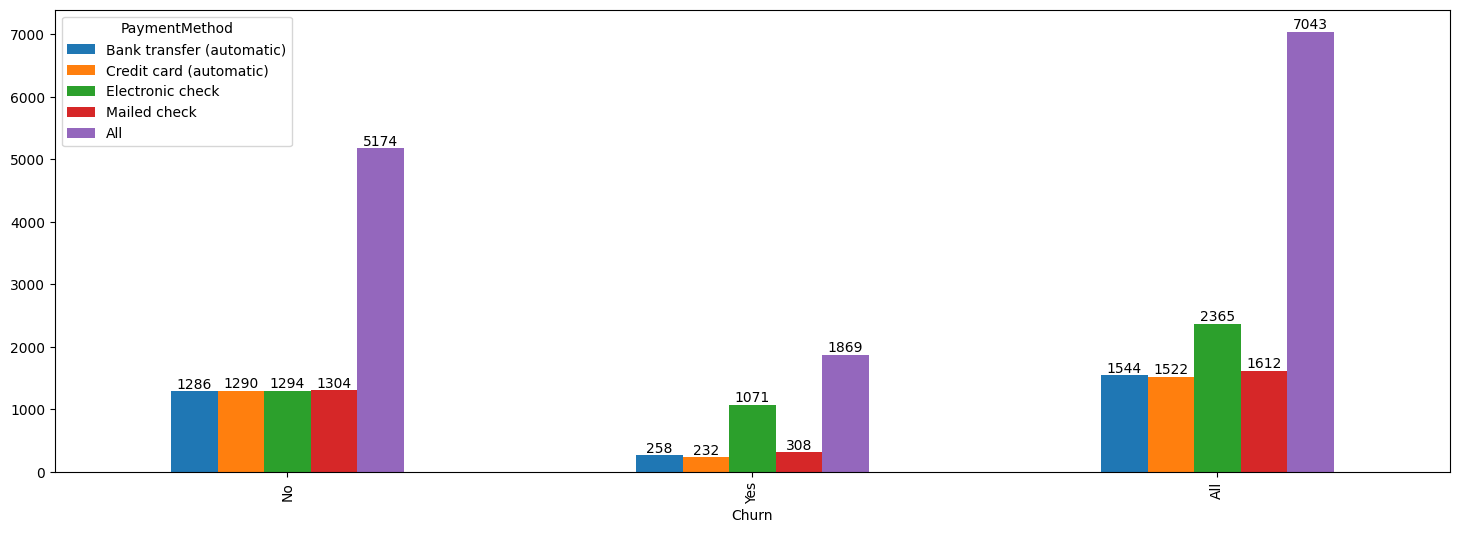

In [56]:

viz=pd.crosstab(index=df['Churn'],columns=df['PaymentMethod'],margins=True).plot(kind="bar",figsize=(18, 6))

for container in viz.containers:
    viz.bar_label(container,fmt="%d")

plt.show()